In [ ]:
# Import necessary libraries
import pandas as pd        # For data manipulation and analysis
import matplotlib.pyplot as plt  # For plotting and visualization
import matplotlib.image as mpimg  # For reading images
import numpy as np         # For numerical operations
import scipy               # For scientific computations
import itertools           # For advanced iteration
from datetime import datetime  # For handling date and time

In [ ]:
import zipfile
import os
zip_path = "/content/ECG Heartbeat Categorization Dataset.zip"
extract_path = "/content/Heartbeat"  # Dossier où extraire

# Créer le dossier s'il n'existe pas
os.makedirs(extract_path, exist_ok=True)

# Extraire le ZIP
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction terminée ! Les fichiers sont dans :", extract_path)

Extraction terminée ! Les fichiers sont dans : /content/Heartbeat


<Figure size 640x480 with 0 Axes>

Epoch 100/100 - Loss:0.0130 Train Acc:99.55% Val Acc:98.66% Train F1:0.9677 Val F1:0.9276
Training time: 0:30:09.975861


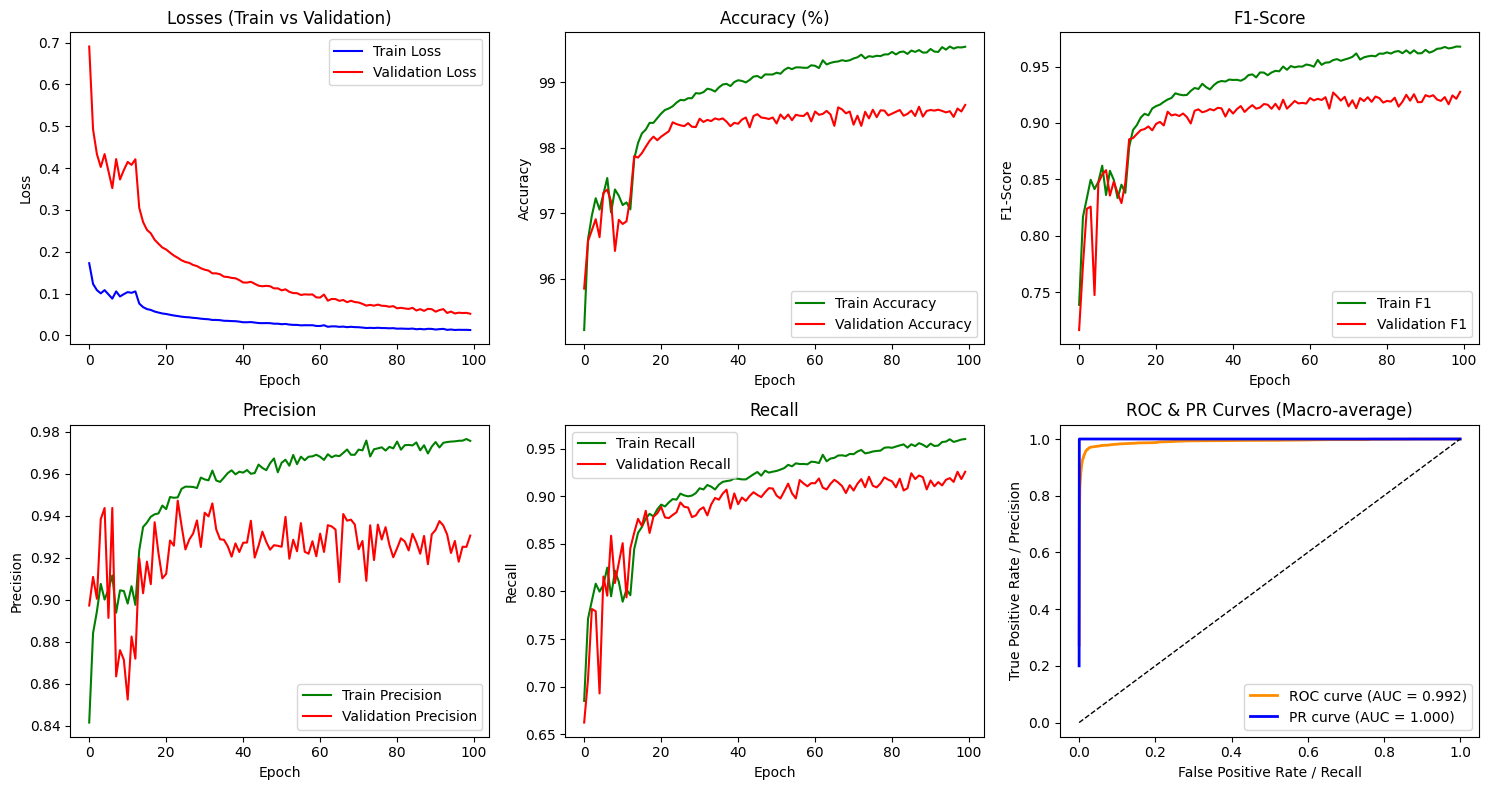

In [ ]:
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, roc_auc_score, roc_curve, precision_recall_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
from datetime import datetime
import shap
import torch.optim as optim

# ========================  MSEE pre-detector  ========================
def compute_msee_score(x: torch.Tensor, eps: float = 1e-12) -> torch.Tensor:
    B, C, T = x.shape
    xm = x.mean(dim=2, keepdim=True)
    x_cent = x - xm  # center the signal

    if C == 1:
        d_emb = min(8, max(1, T // 8))
        if d_emb <= 1:
            return torch.ones(B, device=x.device)
        H = x_cent.squeeze(1).unfold(1, d_emb, 1)  # (B, cols, d_emb)
        H = H.permute(0, 2, 1)  # (B, d_emb, cols)
        cov = torch.bmm(H, H.transpose(1, 2)) / H.shape[2]  # (B, d_emb, d_emb)
    else:
        cov = torch.bmm(x_cent, x_cent.transpose(1,2)) / T  # (B, C, C)

    cov = 0.5 * (cov + cov.transpose(1,2))  # symmetric
    eigs = torch.linalg.eigvalsh(cov)  # (B, d_emb or C)
    eigs = torch.clamp(eigs, min=eps)
    lam_max = eigs[:, -1]
    lam_min = eigs[:, 0]
    scores = (lam_max + lam_min) / (2.0 * torch.sqrt(lam_max * lam_min + eps))
    return scores

# ========================  Model  ========================
class CNNFeatureExtractor(nn.Module):
    def __init__(self, in_channels=1, channels=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, channels//2, kernel_size=11, padding=5),
            nn.BatchNorm1d(channels//2), nn.ELU(), nn.MaxPool1d(2),
            nn.Conv1d(channels//2, channels, kernel_size=7, padding=3),
            nn.BatchNorm1d(channels), nn.ELU(), nn.MaxPool1d(2),
            nn.Conv1d(channels, channels, kernel_size=5, padding=2),
            nn.BatchNorm1d(channels), nn.ELU()
        )
    def forward(self, x): return self.net(x)

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float()
                             * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1), :]

class DeepECG_MSEE_Net(nn.Module):
    def __init__(self, num_classes=5, msee_threshold=1.01):
        super().__init__()
        self.cnn = CNNFeatureExtractor(1, 64)
        self.proj = nn.Conv1d(64, 128, kernel_size=1)
        enc_layer = nn.TransformerEncoderLayer(d_model=128, nhead=4,
                                               dim_feedforward=512,
                                               dropout=0.1, batch_first=True)
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)
        self.pos = PositionalEncoding(128, max_len=2000)
        self.gating = nn.Sequential(nn.Linear(1,32), nn.ELU(),
                                    nn.Linear(32,1), nn.ELU())
        self.msee_thr = msee_threshold
        self.classifier = nn.Sequential(nn.AdaptiveAvgPool1d(1),
                                        nn.Flatten(),
                                        nn.Linear(128, num_classes))
    def forward(self, x):
        scores = compute_msee_score(x)
        g = self.gating((scores - self.msee_thr).unsqueeze(1))
        feat = self.cnn(x)
        feat = self.proj(feat)
        feat = feat.permute(0,2,1)
        feat = self.pos(feat) * g.unsqueeze(2)
        feat = self.transformer(feat)
        feat = feat.permute(0,2,1)
        logits = self.classifier(feat)
        return logits, scores

# ========================  Data  ========================
train = pd.read_csv('/content/Heartbeat/mitbih_train.csv', header=None)
test  = pd.read_csv('/content/Heartbeat/mitbih_test.csv',  header=None)
X_train, y_train = train.iloc[:,:187], train[187]
X_test,  y_test  = test.iloc[:,:187], test[187]

# Normalization per sample
X_train = (X_train.values - X_train.values.mean(axis=1, keepdims=True)) / (X_train.values.std(axis=1, keepdims=True)+1e-6)
X_test  = (X_test.values  - X_test.values.mean(axis=1, keepdims=True))  / (X_test.values.std(axis=1, keepdims=True)+1e-6)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32).unsqueeze(1)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.long)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).unsqueeze(1)
y_test_tensor  = torch.tensor(y_test.values, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor),
                          batch_size=64, shuffle=True, num_workers=2)
test_loader  = DataLoader(TensorDataset(X_test_tensor, y_test_tensor),
                          batch_size=64, num_workers=2)

# ========================  Training with live plots and all metrics  ========================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = DeepECG_MSEE_Net(num_classes=5).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# Learning rate scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=5)

# Early stopping parameters
best_val_loss = float('inf')
patience_counter = 0
early_stopping_patience = 10  # Number of epochs to wait before stopping if no improvement

train_losses, val_losses, val_accs = [], [], []
train_precision, train_recall, train_f1 = [], [], []
val_precision, val_recall, val_f1 = [], [], []
train_accs = [] # Initialize train_accs here
num_epochs = 100
start_time = datetime.now()

plt.ion()
fig, ax = plt.subplots(2, 3, figsize=(15,8))

for epoch in range(num_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    all_train_preds, all_train_labels = [], []
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        outputs, _ = model(xb)
        loss = criterion(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * xb.size(0)
        preds = outputs.argmax(1)
        all_train_preds.append(preds.cpu().numpy())
        all_train_labels.append(yb.cpu().numpy())
        correct += (preds == yb).sum().item()
        total += yb.size(0)

    all_train_preds = np.concatenate(all_train_preds)
    all_train_labels = np.concatenate(all_train_labels)

    train_losses.append(running_loss/total)
    train_accs.append(100*correct/total)

    # Calculate training metrics
    train_precision.append(precision_score(all_train_labels, all_train_preds, average='macro'))
    train_recall.append(recall_score(all_train_labels, all_train_preds, average='macro'))
    train_f1.append(f1_score(all_train_labels, all_train_preds, average='macro'))

    # Validation
    model.eval()
    correct, total = 0, 0
    all_val_preds, all_val_labels, all_val_probs = [], [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            out, _ = model(xb)
            probs = F.softmax(out, dim=1)
            pred = out.argmax(1)
            all_val_preds.append(pred.cpu().numpy())
            all_val_labels.append(yb.cpu().numpy())
            all_val_probs.append(probs.cpu().numpy())
            correct += (pred == yb).sum().item()
            total += yb.size(0)

    all_val_preds = np.concatenate(all_val_preds)
    all_val_labels = np.concatenate(all_val_labels)
    all_val_probs = np.concatenate(all_val_probs)

    val_losses.append(running_loss/total)
    val_accs.append(100*correct/total)

    # Calculate validation metrics
    val_precision.append(precision_score(all_val_labels, all_val_preds, average='macro'))
    val_recall.append(recall_score(all_val_labels, all_val_preds, average='macro'))
    val_f1.append(f1_score(all_val_labels, all_val_preds, average='macro'))

    # Early stopping check
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        patience_counter = 0  # Reset patience counter
    else:
        patience_counter += 1
        if patience_counter >= early_stopping_patience:
            print(f"Early stopping at epoch {epoch+1} due to no improvement.")
            break

    scheduler.step(val_losses[-1])  # Adjust learning rate based on validation loss

    clear_output(wait=True)
    ax[0, 0].cla(); ax[0, 1].cla(); ax[0, 2].cla()
    ax[1, 0].cla(); ax[1, 1].cla(); ax[1, 2].cla()

    # Update plots for monitoring training process
    ax[0, 0].plot(train_losses, 'b-', label='Train Loss')
    ax[0, 0].plot(val_losses, 'r-', label='Validation Loss')
    ax[0, 0].set_title('Losses (Train vs Validation)')
    ax[0, 0].set_xlabel('Epoch')
    ax[0, 0].set_ylabel('Loss')
    ax[0, 0].legend()

    ax[0, 1].plot(train_accs, 'g-', label='Train Accuracy')
    ax[0, 1].plot(val_accs, 'r-', label='Validation Accuracy')
    ax[0, 1].set_title('Accuracy (%)')
    ax[0, 1].set_xlabel('Epoch')
    ax[0, 1].set_ylabel('Accuracy')
    ax[0, 1].legend()

    ax[0, 2].plot(train_f1, 'g-', label='Train F1')
    ax[0, 2].plot(val_f1, 'r-', label='Validation F1')
    ax[0, 2].set_title('F1-Score')
    ax[0, 2].set_xlabel('Epoch')
    ax[0, 2].set_ylabel('F1-Score')
    ax[0, 2].legend()

    ax[1, 0].plot(train_precision, 'g-', label='Train Precision')
    ax[1, 0].plot(val_precision, 'r-', label='Validation Precision')
    ax[1, 0].set_title('Precision')
    ax[1, 0].set_xlabel('Epoch')
    ax[1, 0].set_ylabel('Precision')
    ax[1, 0].legend()

    ax[1, 1].plot(train_recall, 'g-', label='Train Recall')
    ax[1, 1].plot(val_recall, 'r-', label='Validation Recall')
    ax[1, 1].set_title('Recall')
    ax[1, 1].set_xlabel('Epoch')
    ax[1, 1].set_ylabel('Recall')
    ax[1, 1].legend()

    # Add ROC/PR curves (as before)
    n_classes = all_val_probs.shape[1]
    y_true_one_hot = np.eye(n_classes)[all_val_labels]

    # ROC curve
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(y_true_one_hot[:, i], all_val_probs[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Averages
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # PR curve
    precision = dict()
    recall = dict()
    pr_auc = dict()
    for i in range(n_classes):
        precision[i], recall[i], _ = precision_recall_curve(y_true_one_hot[:, i], all_val_probs[:, i])
        pr_auc[i] = auc(recall[i], precision[i])

    # Averages
    all_recall = np.unique(np.concatenate([recall[i] for i in range(n_classes)]))
    mean_precision = np.zeros_like(all_recall)
    for i in range(n_classes):
        mean_precision += np.interp(all_recall, recall[i], precision[i])
    mean_precision /= n_classes
    recall["macro"] = all_recall
    precision["macro"] = mean_precision
    # Calculate macro PR AUC for plotting
    pr_auc_macro = auc(recall["macro"], precision["macro"])

    ax[1, 2].plot(fpr["macro"], tpr["macro"], color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc["macro"]:.3f})')
    ax[1, 2].plot(recall["macro"], precision["macro"], color='blue', lw=2, label=f'PR curve (AUC = {pr_auc_macro:.3f})')
    ax[1, 2].set_title('ROC & PR Curves (Macro-average)')
    ax[1, 2].set_xlabel('False Positive Rate / Recall')
    ax[1, 2].set_ylabel('True Positive Rate / Precision')
    ax[1, 2].legend(loc="lower right")
    ax[1, 2].plot([0, 1], [0, 1], 'k--', lw=1)  # Add diagonal line for ROC

    plt.tight_layout()
    plt.show()

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_losses[-1]:.4f} "
          f"Train Acc:{train_accs[-1]:.2f}% " # Changed from val_accs to train_accs
          f"Val Acc:{val_accs[-1]:.2f}% "
          f"Train F1:{train_f1[-1]:.4f} "
          f"Val F1:{val_f1[-1]:.4f}")

print("Training time:", datetime.now() - start_time)

# ========================  Post-Training Visualizations  ========================
def plot_training_curves(train_losses, val_losses, train_accs, val_accs,
                         train_f1, val_f1, train_precision, val_precision,
                         train_recall, val_recall, fpr, tpr, roc_auc,
                         recall_macro_arr, precision_macro_arr, pr_auc_macro):
    """
    Cette fonction trace les courbes d'apprentissage après la fin de l'entraînement.
    """
    # Création de la figure et des axes pour les courbes
    fig, ax = plt.subplots(2, 3, figsize=(15, 8))

    # Courbes de perte (loss)
    ax[0, 0].plot(train_losses, 'b-', label='Train Loss')
    ax[0, 0].plot(val_losses, 'r-', label='Validation Loss')
    ax[0, 0].set_title('Losses (Train vs Validation)')
    ax[0, 0].set_xlabel('Epoch')
    ax[0, 0].set_ylabel('Loss')
    ax[0, 0].legend()

    # Courbes de précision (accuracy)
    ax[0, 1].plot(train_accs, 'g-', label='Train Accuracy')
    ax[0, 1].plot(val_accs, 'r-', label='Validation Accuracy')
    ax[0, 1].set_title('Accuracy (%)')
    ax[0, 1].set_xlabel('Epoch')
    ax[0, 1].set_ylabel('Accuracy')
    ax[0, 1].legend()

    # Courbes de F1-score
    ax[0, 2].plot(train_f1, 'g-', label='Train F1')
    ax[0, 2].plot(val_f1, 'r-', label='Validation F1')
    ax[0, 2].set_title('F1-Score')
    ax[0, 2].set_xlabel('Epoch')
    ax[0, 2].set_ylabel('F1-Score')
    ax[0, 2].legend()

    # Courbes de précision
    ax[1, 0].plot(train_precision, 'g-', label='Train Precision')
    ax[1, 0].plot(val_precision, 'r-', label='Validation Precision')
    ax[1, 0].set_title('Precision')
    ax[1, 0].set_xlabel('Epoch')
    ax[1, 0].set_ylabel('Precision')
    ax[1, 0].legend()

    # Courbes de rappel (recall)
    ax[1, 1].plot(train_recall, 'g-', label='Train Recall')
    ax[1, 1].plot(val_recall, 'r-', label='Validation Recall')
    ax[1, 1].set_title('Recall')
    ax[1, 1].set_xlabel('Epoch')
    ax[1, 1].set_ylabel('Recall')
    ax[1, 1].legend()

    # Courbes ROC et PR
    ax[1, 2].plot(fpr["macro"], tpr["macro"], color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc["macro"]:.3f})')
    ax[1, 2].plot(recall_macro_arr, precision_macro_arr, color='blue', lw=2, label=f'PR curve (AUC = {pr_auc_macro:.3f})')
    ax[1, 2].set_title('ROC & PR Curves (Macro-average)')
    ax[1, 2].set_xlabel('False Positive Rate / Recall')
    ax[1, 2].set_ylabel('True Positive Rate / Precision')
    ax[1, 2].legend(loc="lower right")
    ax[1, 2].plot([0, 1], [0, 1], 'k--', lw=1)  # Add diagonal line for ROC

    plt.tight_layout()
    plt.show()

# ========================  Call the function after training ends  ========================
# Calculate macro PR AUC before calling the plotting function
pr_auc_macro_final = auc(recall["macro"], precision["macro"])

plot_training_curves(train_losses, val_losses, train_accs, val_accs,
                     train_f1, val_f1, train_precision, val_precision,
                     train_recall, val_recall, fpr, tpr, roc_auc,
                     recall["macro"], precision["macro"], pr_auc_macro_final)